In [2]:
pip install spatialmath-python roboticstoolbox-python numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.8/193.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 2.8 MB/s eta 0:00:00


In [3]:
# ================================================================
# IMPORT REQUIRED LIBRARIES
# ================================================================

from spatialmath import SE2, SE3
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ================================================================
# HELPER FUNCTIONS
# ================================================================

def print_header(title):
    """
    Prints a formatted heading for each task.
    """
    print("\n")
    print("=" * 75)
    print(title)
    print("=" * 75)


def print_matrix(name, T):
    """
    Prints a transformation matrix with a label.
    """
    print(f"\n{name}")
    print("-" * 50)
    print(T)


def print_position_orientation_2d(T):
    """
    Extracts and prints final X, Y position
    and orientation from an SE2 transformation.
    """

    # Translation component
    x = T.t[0]
    y = T.t[1]

    # Rotation angle in radians
    theta = T.theta()

    # Convert radians to degrees
    theta_deg = np.degrees(theta)

    print(f"Final X Position       : {x:.4f}")
    print(f"Final Y Position       : {y:.4f}")
    print(f"Final Orientation      : {theta_deg:.4f} degrees")


def print_position_orientation_3d(T):
    """
    Extracts and prints final X, Y, Z position
    and rotation matrix from an SE3 transformation.
    """

    # Translation component
    x = T.t[0]
    y = T.t[1]
    z = T.t[2]

    print(f"Final X Position       : {x:.4f}")
    print(f"Final Y Position       : {y:.4f}")
    print(f"Final Z Position       : {z:.4f}")

    print("\nFinal Rotation Matrix:")
    print(T.R)


Trial 1
Translation = (4, 3)

Homogeneous Transformation Matrix
--------------------------------------------------
   1         0         4         
   0         1         3         
   0         0         1         


Final Position:
Final X Position       : 4.0000
Final Y Position       : 3.0000
Final Orientation      : 0.0000 degrees

Trial 2
Translation = (2, 5)

Homogeneous Transformation Matrix
--------------------------------------------------
   1         0         2         
   0         1         5         
   0         0         1         


Final Position:
Final X Position       : 2.0000
Final Y Position       : 5.0000
Final Orientation      : 0.0000 degrees

Trial 3
Translation = (5, 1)

Homogeneous Transformation Matrix
--------------------------------------------------
   1         0         5         
   0         1         1         
   0         0         1         


Final Position:
Final X Position       : 5.0000
Final Y Position       : 1.0000
Final Orientation   

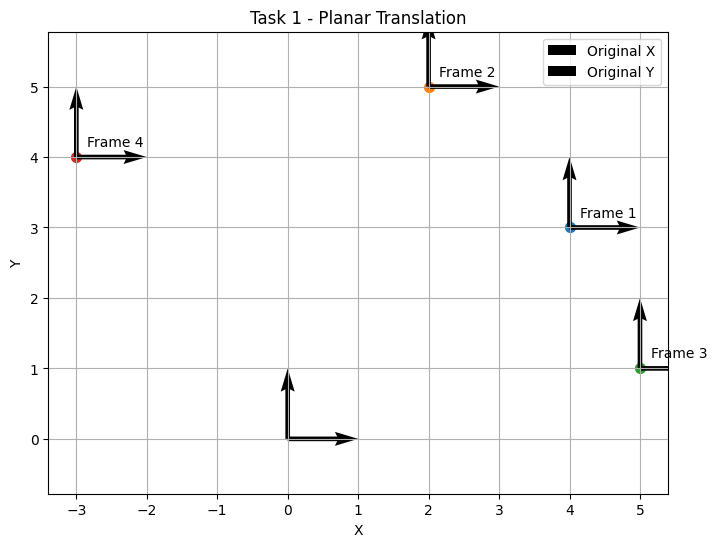

In [5]:
# ================================================================
# PART A - PLANAR MECHANISM (SE2)
# ================================================================


# ================================================================
# TASK 1 - PLANAR TRANSLATION
# ================================================================

translations_2d = [
    (4, 3),
    (2, 5),
    (5, 1),
    (-3, 4)
]


for i, (x, y) in enumerate(translations_2d, start=1):

    print(f"\nTrial {i}")
    print(f"Translation = ({x}, {y})")

    # Create planar translation matrix
    T = SE2(x, y)

    # Display matrix
    print_matrix("Homogeneous Transformation Matrix", T)

    # Determine final position
    print("\nFinal Position:")
    print_position_orientation_2d(T)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot original coordinate frame
origin = SE2(0, 0)

ax.quiver(0, 0, 1, 0,
          angles='xy',
          scale_units='xy',
          scale=1,
          label="Original X")

ax.quiver(0, 0, 0, 1,
          angles='xy',
          scale_units='xy',
          scale=1,
          label="Original Y")

# Plot transformed coordinate frames
for i, (x, y) in enumerate(translations_2d, start=1):

    ax.scatter(x, y, s=50)

    ax.text(x + 0.15, y + 0.15, f"Frame {i}")

    # X axis
    ax.quiver(x, y, 1, 0,
              angles='xy',
              scale_units='xy',
              scale=1)

    # Y axis
    ax.quiver(x, y, 0, 1,
              angles='xy',
              scale_units='xy',
              scale=1)

ax.set_title("Task 1 - Planar Translation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")
ax.legend()

plt.show()



Rotation = 60 degrees

Rotation Transformation Matrix
--------------------------------------------------
   0.5      -0.866     0         
   0.866     0.5       0         
   0         0         1         

Final Orientation = 60 degrees

Rotation = 30 degrees

Rotation Transformation Matrix
--------------------------------------------------
   0.866    -0.5       0         
   0.5       0.866     0         
   0         0         1         

Final Orientation = 30 degrees

Rotation = 90 degrees

Rotation Transformation Matrix
--------------------------------------------------
   0        -1         0         
   1         0         0         
   0         0         1         

Final Orientation = 90 degrees

Rotation = 120 degrees

Rotation Transformation Matrix
--------------------------------------------------
  -0.5      -0.866     0         
   0.866    -0.5       0         
   0         0         1         

Final Orientation = 120 degrees

Rotation = 180 degrees

Rotation Tran

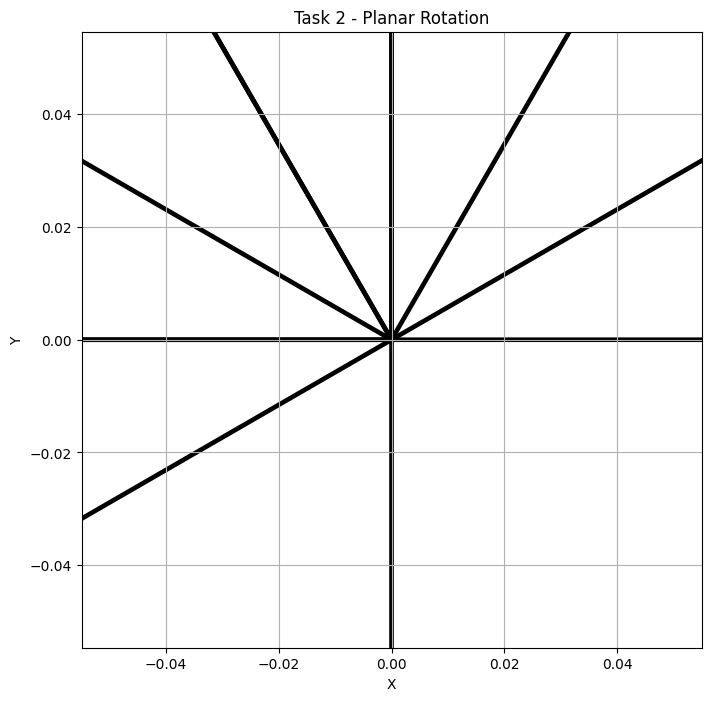

In [6]:
# ================================================================
# TASK 2 - PLANAR ROTATION
# ================================================================

rotation_angles_2d = [60, 30, 90, 120, 180]


for angle in rotation_angles_2d:

    print(f"\nRotation = {angle} degrees")

    # Create rotation matrix
    R = SE2.Rot(angle, "deg")

    # Display matrix
    print_matrix("Rotation Transformation Matrix", R)

    # Determine orientation
    print(f"Final Orientation = {angle} degrees")

fig, ax = plt.subplots(figsize=(8, 8))

# Original X axis
ax.quiver(0, 0, 1, 0,
          angles='xy',
          scale_units='xy',
          scale=1)

# Original Y axis
ax.quiver(0, 0, 0, 1,
          angles='xy',
          scale_units='xy',
          scale=1)

for angle in rotation_angles_2d:

    R = SE2.Rot(angle, "deg")

    # Extract rotated X and Y axes
    x_axis = R.R[:, 0]
    y_axis = R.R[:, 1]

    ax.quiver(0, 0,
              x_axis[0],
              x_axis[1],
              angles='xy',
              scale_units='xy',
              scale=1)

    ax.quiver(0, 0,
              y_axis[0],
              y_axis[1],
              angles='xy',
              scale_units='xy',
              scale=1)

ax.set_title("Task 2 - Planar Rotation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")

plt.show()



In [ ]:
# ================================================================
# TASK 3 - PLANAR TRANSLATION AND ROTATION
# ================================================================

task3_cases = [
    ((3, 2), 45),
    ((5, 1), 60),
    ((2, 4), 90)
]


for i, ((x, y), angle) in enumerate(task3_cases, start=1):

    print(f"\nCase {i}")
    print(f"Translation = ({x}, {y})")
    print(f"Rotation = {angle} degrees")

    # Translation
    T = SE2(x, y)

    # Rotation
    R = SE2.Rot(angle, "deg")

    print_matrix("Translation Matrix", T)
    print_matrix("Rotation Matrix", R)

    # Combine transformation
    H = T * R

    print_matrix("Final Homogeneous Transformation", H)

    # Final position and orientation
    print("\nFinal Position and Orientation:")
    print_position_orientation_2d(H)

fig, ax = plt.subplots(figsize=(8, 6))

for i, ((x, y), angle) in enumerate(task3_cases, start=1):

    H = SE2(x, y) * SE2.Rot(angle, "deg")

    # Position
    px = H.t[0]
    py = H.t[1]

    # Rotated X-axis
    x_axis = H.R[:, 0]

    # Rotated Y-axis
    y_axis = H.R[:, 1]

    ax.scatter(px, py, s=50)

    ax.text(px + 0.1, py + 0.1, f"Case {i}")

    ax.quiver(px, py,
              x_axis[0],
              x_axis[1],
              angles='xy',
              scale_units='xy',
              scale=1)

    ax.quiver(px, py,
              y_axis[0],
              y_axis[1],
              angles='xy',
              scale_units='xy',
              scale=1)

ax.set_title("Task 3 - Planar Translation and Rotation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")

plt.show()


Case A - Translation followed by Rotation
--------------------------------------------------
   0        -1         4         
   1         0         2         
   0         0         1         


Case A Position and Orientation:
Final X Position       : 4.0000
Final Y Position       : 2.0000
Final Orientation      : 90.0000 degrees

Case B - Rotation followed by Translation
--------------------------------------------------
   0        -1        -2         
   1         0         4         
   0         0         1         


Case B Position and Orientation:
Final X Position       : -2.0000
Final Y Position       : 4.0000
Final Orientation      : 90.0000 degrees

Comparison:
Are the matrices identical? False

Explanation:
Transformation multiplication is not commutative.

Therefore:

T * R != R * T

Changing the order changes the final position and/or orientation.



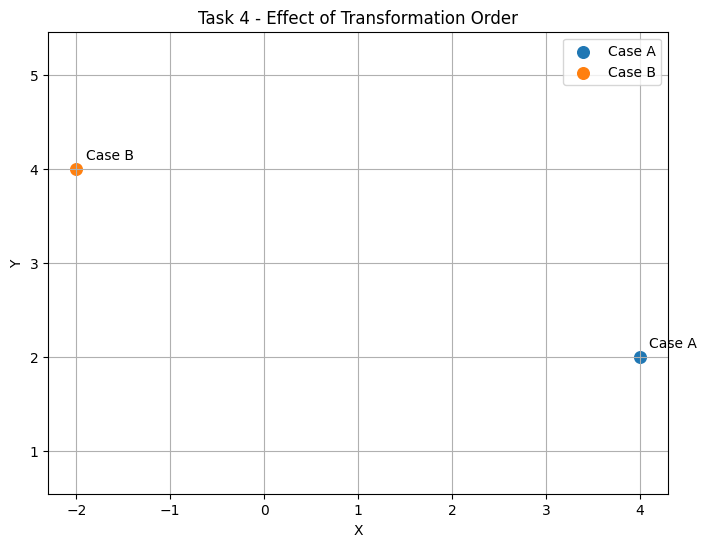

In [7]:
# ================================================================
# TASK 4 - EFFECT OF TRANSFORMATION ORDER
# ================================================================

T = SE2(4, 2)
R = SE2.Rot(90, "deg")


# Case A
case_A = T * R

# Case B
case_B = R * T


print_matrix("Case A - Translation followed by Rotation", case_A)

print("\nCase A Position and Orientation:")
print_position_orientation_2d(case_A)


print_matrix("Case B - Rotation followed by Translation", case_B)

print("\nCase B Position and Orientation:")
print_position_orientation_2d(case_B)


print("\nComparison:")
print("Are the matrices identical?", np.allclose(case_A.A, case_B.A))

print("""
Explanation:
Transformation multiplication is not commutative.

Therefore:

T * R != R * T

Changing the order changes the final position and/or orientation.
""")

fig, ax = plt.subplots(figsize=(8, 6))

# Case A
ax.scatter(case_A.t[0], case_A.t[1], s=70,
           label="Case A")

ax.text(case_A.t[0] + 0.1,
        case_A.t[1] + 0.1,
        "Case A")

# Case B
ax.scatter(case_B.t[0], case_B.t[1], s=70,
           label="Case B")

ax.text(case_B.t[0] + 0.1,
        case_B.t[1] + 0.1,
        "Case B")

ax.set_title("Task 4 - Effect of Transformation Order")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")
ax.legend()

plt.show()


Operation 1 - Translation (2,1)
--------------------------------------------------
   1         0         2         
   0         1         1         
   0         0         1         


Operation 2 - Rotation 30 degrees
--------------------------------------------------
   0.866    -0.5       0         
   0.5       0.866     0         
   0         0         1         


Operation 3 - Translation (3,2)
--------------------------------------------------
   1         0         3         
   0         1         2         
   0         0         1         


Operation 4 - Rotation 45 degrees
--------------------------------------------------
   0.7071   -0.7071    0         
   0.7071    0.7071    0         
   0         0         1         


Final Sequential Transformation
--------------------------------------------------
   0.2588   -0.9659    3.598     
   0.9659    0.2588    4.232     
   0         0         1         


Final Position and Orientation:
Final X Position       : 3.5

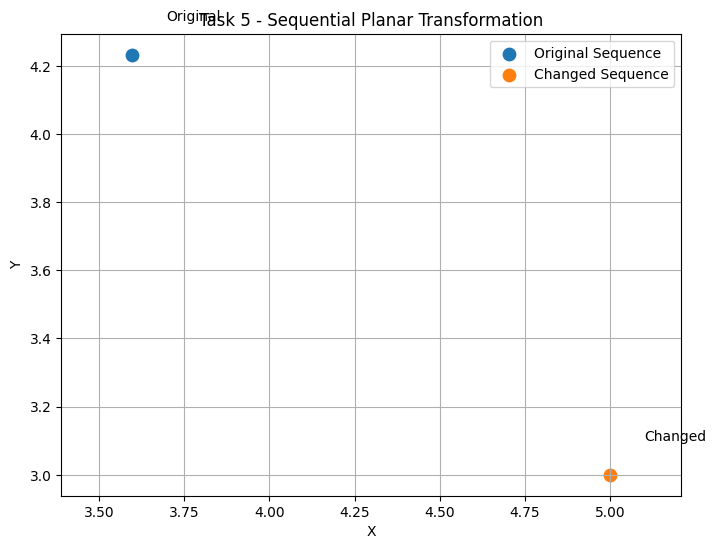

In [8]:
# ================================================================
# TASK 5 - SEQUENTIAL PLANAR TRANSFORMATION
# ================================================================

T1 = SE2(2, 1)
R1 = SE2.Rot(30, "deg")
T2 = SE2(3, 2)
R2 = SE2.Rot(45, "deg")


print_matrix("Operation 1 - Translation (2,1)", T1)
print_matrix("Operation 2 - Rotation 30 degrees", R1)
print_matrix("Operation 3 - Translation (3,2)", T2)
print_matrix("Operation 4 - Rotation 45 degrees", R2)


# Correct sequence
H5 = T1 * R1 * T2 * R2

print_matrix("Final Sequential Transformation", H5)

print("\nFinal Position and Orientation:")
print_position_orientation_2d(H5)


# ---------------------------------------------------------------
# Change order
# ---------------------------------------------------------------

H5_changed = T1 * T2 * R1 * R2

print_matrix("Transformation After Changing Order", H5_changed)

print("\nComparison:")
print("Original and changed matrices identical?",
      np.allclose(H5.A, H5_changed.A))

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(H5.t[0], H5.t[1],
           s=80,
           label="Original Sequence")

ax.scatter(H5_changed.t[0],
           H5_changed.t[1],
           s=80,
           label="Changed Sequence")

ax.text(H5.t[0] + 0.1,
        H5.t[1] + 0.1,
        "Original")

ax.text(H5_changed.t[0] + 0.1,
        H5_changed.t[1] + 0.1,
        "Changed")

ax.set_title("Task 5 - Sequential Planar Transformation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")
ax.legend()

plt.show()


Case 1
Translation = (3, 4, 2)

SE3 Transformation Matrix
--------------------------------------------------
   1         0         0         3         
   0         1         0         4         
   0         0         1         2         
   0         0         0         1         


Final Position:
Final X Position       : 3.0000
Final Y Position       : 4.0000
Final Z Position       : 2.0000

Final Rotation Matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Case 2
Translation = (5, 2, 3)

SE3 Transformation Matrix
--------------------------------------------------
   1         0         0         5         
   0         1         0         2         
   0         0         1         3         
   0         0         0         1         


Final Position:
Final X Position       : 5.0000
Final Y Position       : 2.0000
Final Z Position       : 3.0000

Final Rotation Matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Case 3
Translation = (-2, 4, 5)

SE3 Transformation Matrix
------------------

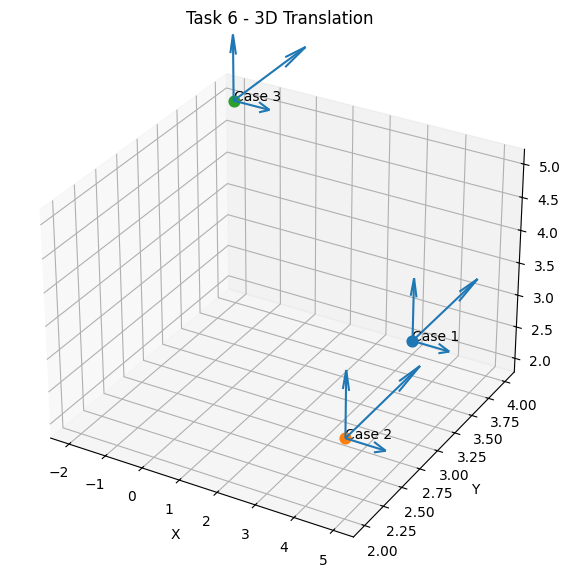

In [9]:
# ================================================================
# PART B - SPATIAL MECHANISM (SE3)
# ================================================================


# ================================================================
# TASK 6 - 3D TRANSLATION
# ================================================================

translations_3d = [
    (3, 4, 2),
    (5, 2, 3),
    (-2, 4, 5)
]


for i, (x, y, z) in enumerate(translations_3d, start=1):

    print(f"\nCase {i}")
    print(f"Translation = ({x}, {y}, {z})")

    T = SE3(x, y, z)

    print_matrix("SE3 Transformation Matrix", T)

    print("\nFinal Position:")
    print_position_orientation_3d(T)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

for i, (x, y, z) in enumerate(translations_3d, start=1):

    ax.scatter(x, y, z, s=60)

    ax.text(x, y, z, f"Case {i}")

    # X axis
    ax.quiver(x, y, z,
              1, 0, 0,
              length=1)

    # Y axis
    ax.quiver(x, y, z,
              0, 1, 0,
              length=1)

    # Z axis
    ax.quiver(x, y, z,
              0, 0, 1,
              length=1)

ax.set_title("Task 6 - 3D Translation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()




Rotation about X-axis - 45 degrees
--------------------------------------------------
   1         0         0         0         
   0         0.7071   -0.7071    0         
   0         0.7071    0.7071    0         
   0         0         0         1         


Rotation about Y-axis - 60 degrees
--------------------------------------------------
   0.5       0         0.866     0         
   0         1         0         0         
  -0.866     0         0.5       0         
   0         0         0         1         


Rotation about Z-axis - 90 degrees
--------------------------------------------------
   0        -1         0         0         
   1         0         0         0         
   0         0         1         0         
   0         0         0         1         


Comparison:

Rx rotates around the X-axis.

Ry rotates around the Y-axis.

Rz rotates around the Z-axis.

Each rotation changes a different pair of coordinate axes.



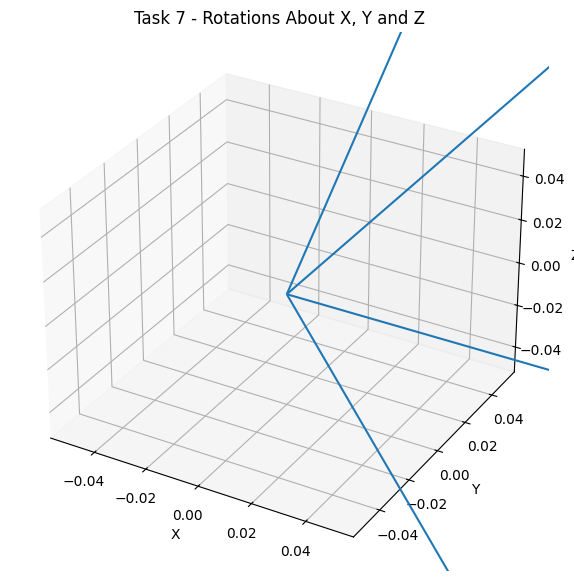

In [10]:
# ================================================================
# TASK 7 - ROTATION ABOUT X, Y AND Z AXES
# ================================================================

Rx = SE3.Rx(45, "deg")
Ry = SE3.Ry(60, "deg")
Rz = SE3.Rz(90, "deg")


print_matrix("Rotation about X-axis - 45 degrees", Rx)
print_matrix("Rotation about Y-axis - 60 degrees", Ry)
print_matrix("Rotation about Z-axis - 90 degrees", Rz)


print("""
Comparison:

Rx rotates around the X-axis.

Ry rotates around the Y-axis.

Rz rotates around the Z-axis.

Each rotation changes a different pair of coordinate axes.
""")

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# X rotation frame
ax.quiver(0, 0, 0, 1, 0, 0, length=1)
ax.quiver(0, 0, 0, 0,
          np.cos(np.radians(45)),
          np.sin(np.radians(45)),
          length=1)

# Y rotation frame
ax.quiver(0, 0, 0,
          np.cos(np.radians(60)),
          0,
          -np.sin(np.radians(60)),
          length=1)

# Z rotation frame
ax.quiver(0, 0, 0,
          np.cos(np.radians(90)),
          np.sin(np.radians(90)),
          0,
          length=1)

ax.set_title("Task 7 - Rotations About X, Y and Z")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


Rotation about X-axis

Translation Matrix
--------------------------------------------------
   1         0         0         2         
   0         1         0         3         
   0         0         1         4         
   0         0         0         1         


Rotation Matrix
--------------------------------------------------
   1         0         0         0         
   0         0.5      -0.866     0         
   0         0.866     0.5       0         
   0         0         0         1         


Final Homogeneous Transformation
--------------------------------------------------
   1         0         0         2         
   0         0.5      -0.866     3         
   0         0.866     0.5       4         
   0         0         0         1         


Final Position and Orientation:
Final X Position       : 2.0000
Final Y Position       : 3.0000
Final Z Position       : 4.0000

Final Rotation Matrix:
[[ 1.         0.         0.       ]
 [ 0.         0.5       -0.866025

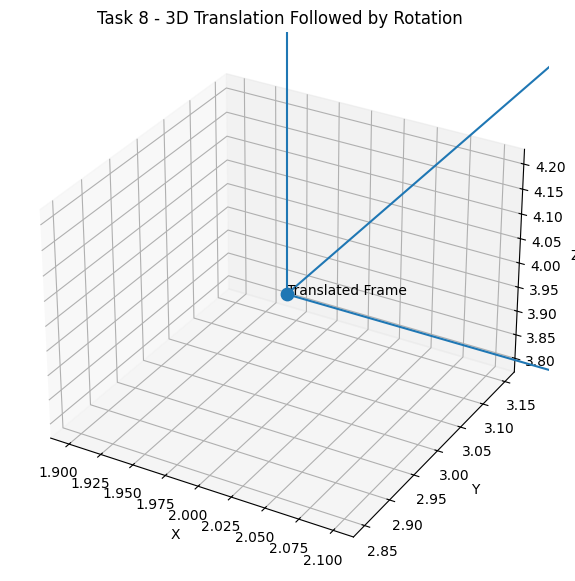

In [11]:
# ================================================================
# TASK 8 - 3D TRANSLATION FOLLOWED BY ROTATION
# ================================================================

translation_3d = SE3(2, 3, 4)

rotation_cases = [
    ("X-axis", SE3.Rx(60, "deg")),
    ("Y-axis", SE3.Ry(60, "deg")),
    ("Z-axis", SE3.Rz(60, "deg"))
]


for axis_name, rotation in rotation_cases:

    print(f"\nRotation about {axis_name}")

    print_matrix("Translation Matrix", translation_3d)
    print_matrix("Rotation Matrix", rotation)

    # Combine transformations
    H8 = translation_3d * rotation

    print_matrix("Final Homogeneous Transformation", H8)

    print("\nFinal Position and Orientation:")
    print_position_orientation_3d(H8)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Common final position
x, y, z = 2, 3, 4

ax.scatter(x, y, z, s=80)

ax.quiver(x, y, z, 1, 0, 0, length=1)
ax.quiver(x, y, z, 0, 1, 0, length=1)
ax.quiver(x, y, z, 0, 0, 1, length=1)

ax.text(x, y, z, "Translated Frame")

ax.set_title("Task 8 - 3D Translation Followed by Rotation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()




Rx - 30 degrees
--------------------------------------------------
   1         0         0         0         
   0         0.866    -0.5       0         
   0         0.5       0.866     0         
   0         0         0         1         


Ry - 45 degrees
--------------------------------------------------
   0.7071    0         0.7071    0         
   0         1         0         0         
  -0.7071    0         0.7071    0         
   0         0         0         1         


Rz - 60 degrees
--------------------------------------------------
   0.5      -0.866     0         0         
   0.866     0.5       0         0         
   0         0         1         0         
   0         0         0         1         


Combined Rotation - X -> Y -> Z
--------------------------------------------------
   0.3536   -0.6124    0.7071    0         
   0.9268    0.1268   -0.3536    0         
   0.1268    0.7803    0.6124    0         
   0         0         0         1         


Com

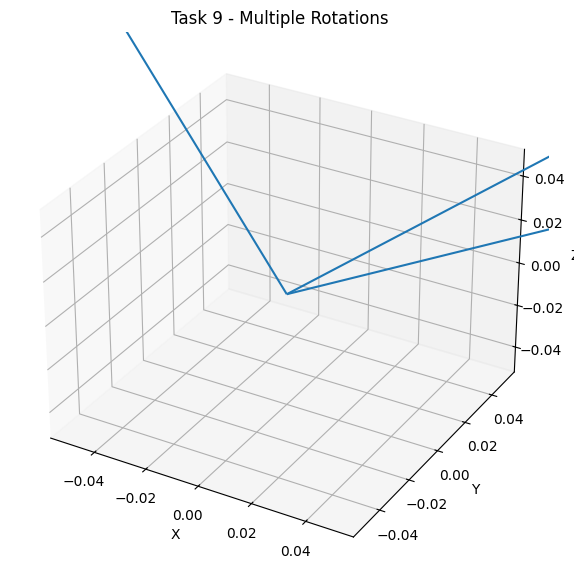

In [12]:
# ================================================================
# TASK 9 - MULTIPLE ROTATIONS
# ================================================================

Rx9 = SE3.Rx(30, "deg")
Ry9 = SE3.Ry(45, "deg")
Rz9 = SE3.Rz(60, "deg")


print_matrix("Rx - 30 degrees", Rx9)
print_matrix("Ry - 45 degrees", Ry9)
print_matrix("Rz - 60 degrees", Rz9)


# Original order
H9_forward = Rx9 * Ry9 * Rz9

print_matrix("Combined Rotation - X -> Y -> Z", H9_forward)


# Reverse order
H9_reverse = Rz9 * Ry9 * Rx9

print_matrix("Combined Rotation - Z -> Y -> X", H9_reverse)


print("\nComparison:")
print("Are the two results identical?",
      np.allclose(H9_forward.A, H9_reverse.A))


print("""
Explanation:

Rotations about different axes do not generally commute.

Therefore:

Rx * Ry * Rz != Rz * Ry * Rx

The final orientation depends on the order
in which the rotations are performed.
""")

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Forward rotation axes
forward_R = H9_forward.R

ax.quiver(0, 0, 0,
          forward_R[0, 0],
          forward_R[1, 0],
          forward_R[2, 0],
          length=1)

ax.quiver(0, 0, 0,
          forward_R[0, 1],
          forward_R[1, 1],
          forward_R[2, 1],
          length=1)

ax.quiver(0, 0, 0,
          forward_R[0, 2],
          forward_R[1, 2],
          forward_R[2, 2],
          length=1)

ax.set_title("Task 9 - Multiple Rotations")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


Translation (2,3,1)
--------------------------------------------------
   1         0         0         2         
   0         1         0         3         
   0         0         1         1         
   0         0         0         1         


Rotation X - 30 degrees
--------------------------------------------------
   1         0         0         0         
   0         0.866    -0.5       0         
   0         0.5       0.866     0         
   0         0         0         1         


Rotation Y - 45 degrees
--------------------------------------------------
   0.7071    0         0.7071    0         
   0         1         0         0         
  -0.7071    0         0.7071    0         
   0         0         0         1         


Rotation Z - 60 degrees
--------------------------------------------------
   0.5      -0.866     0         0         
   0.866     0.5       0         0         
   0         0         1         0         
   0         0         0         1   

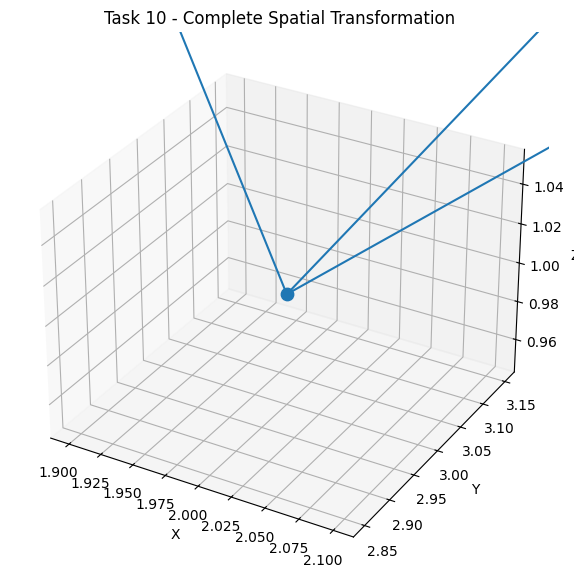

In [13]:
# ================================================================
# TASK 10 - COMPLETE SPATIAL TRANSFORMATION
# ================================================================

T10 = SE3(2, 3, 1)
Rx10 = SE3.Rx(30, "deg")
Ry10 = SE3.Ry(45, "deg")
Rz10 = SE3.Rz(60, "deg")


print_matrix("Translation (2,3,1)", T10)
print_matrix("Rotation X - 30 degrees", Rx10)
print_matrix("Rotation Y - 45 degrees", Ry10)
print_matrix("Rotation Z - 60 degrees", Rz10)


# Given sequence
H10 = T10 * Rx10 * Ry10 * Rz10

print_matrix("Final Transformation - Given Order", H10)

print("\nFinal Position and Orientation:")
print_position_orientation_3d(H10)


# Changed rotation order
H10_changed = T10 * Rz10 * Ry10 * Rx10

print_matrix("Final Transformation - Changed Rotation Order",
              H10_changed)


print("\nAre the transformations identical?",
      np.allclose(H10.A, H10_changed.A))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Final frame
R10 = H10.R
p10 = H10.t

ax.scatter(p10[0], p10[1], p10[2], s=80)

# X-axis
ax.quiver(p10[0], p10[1], p10[2],
          R10[0, 0],
          R10[1, 0],
          R10[2, 0],
          length=1)

# Y-axis
ax.quiver(p10[0], p10[1], p10[2],
          R10[0, 1],
          R10[1, 1],
          R10[2, 1],
          length=1)

# Z-axis
ax.quiver(p10[0], p10[1], p10[2],
          R10[0, 2],
          R10[1, 2],
          R10[2, 2],
          length=1)

ax.set_title("Task 10 - Complete Spatial Transformation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
# ================================================================
# PART C - APPLICATION BASED TASKS
# ================================================================


# ================================================================
# TASK 11 - TWO-LINK PLANAR ROBOT
# ================================================================

L1 = 4
theta1 = 30

L2 = 3
theta2_relative = 45

# Link 1 transformation:
# Rotate Link 1 and then translate along its local X-axis.
T_link1 = SE2.Rot(theta1, "deg") * SE2(L1, 0)


# Link 2 relative transformation:
# Rotate by 45 degrees relative to Link 1 and then translate
# along the local X-axis by length 3.
T_link2_relative = SE2.Rot(theta2_relative, "deg") * SE2(L2, 0)


# Overall transformation
T_link2 = T_link1 * T_link2_relative


print_matrix("Link 1 Transformation", T_link1)
print_matrix("Link 2 Relative Transformation", T_link2_relative)
print_matrix("Overall Two-Link Transformation", T_link2)


print("\nEnd-Effector Position and Orientation:")
print_position_orientation_2d(T_link2)


# ---------------------------------------------------------------
# Calculate Joint Positions
# ---------------------------------------------------------------

joint1_x = T_link1.t[0]
joint1_y = T_link1.t[1]

end_x = T_link2.t[0]
end_y = T_link2.t[1]


# ---------------------------------------------------------------
# Plot Two-Link Robot
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

# Base
ax.scatter(0, 0, s=80)

# Joint 1
ax.scatter(joint1_x, joint1_y, s=80)

# End effector
ax.scatter(end_x, end_y, s=80)

# Link 1
ax.plot([0, joint1_x],
        [0, joint1_y],
        linewidth=3)

# Link 2
ax.plot([joint1_x, end_x],
        [joint1_y, end_y],
        linewidth=3)

# Labels
ax.text(0, 0, "Base")
ax.text(joint1_x, joint1_y, "Joint 1")
ax.text(end_x, end_y, "End Effector")

ax.set_title("Task 11 - Two-Link Planar Robot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")

plt.show()


# ---------------------------------------------------------------
# Change Joint Angles
# ---------------------------------------------------------------

theta1_new = 45
theta2_new = 30

T_link1_new = (
    SE2.Rot(theta1_new, "deg")
    * SE2(L1, 0)
)

T_link2_new = (
    T_link1_new
    * SE2.Rot(theta2_new, "deg")
    * SE2(L2, 0)
)


print("\nAfter Changing Joint Angles:")

print_matrix("New Overall Transformation", T_link2_new)

print("\nNew End-Effector Position and Orientation:")
print_position_orientation_2d(T_link2_new)


Link 1 Transformation
--------------------------------------------------
   0.866    -0.5       0         0         
   0.5       0.866     0         0         
   0         0         1         3         
   0         0         0         1         


Link 2 Transformation
--------------------------------------------------
   0.7071    0         0.7071    2         
   0         1         0         0         
  -0.7071    0         0.7071    0         
   0         0         0         1         


Overall Transformation
--------------------------------------------------
   0.6124   -0.5       0.6124    1.732     
   0.3536    0.866     0.3536    1         
  -0.7071    0         0.7071    3         
   0         0         0         1         


End-Effector Position and Orientation:
Final X Position       : 1.7321
Final Y Position       : 1.0000
Final Z Position       : 3.0000

Final Rotation Matrix:
[[ 0.61237244 -0.5         0.61237244]
 [ 0.35355339  0.8660254   0.35355339]
 [-0.707

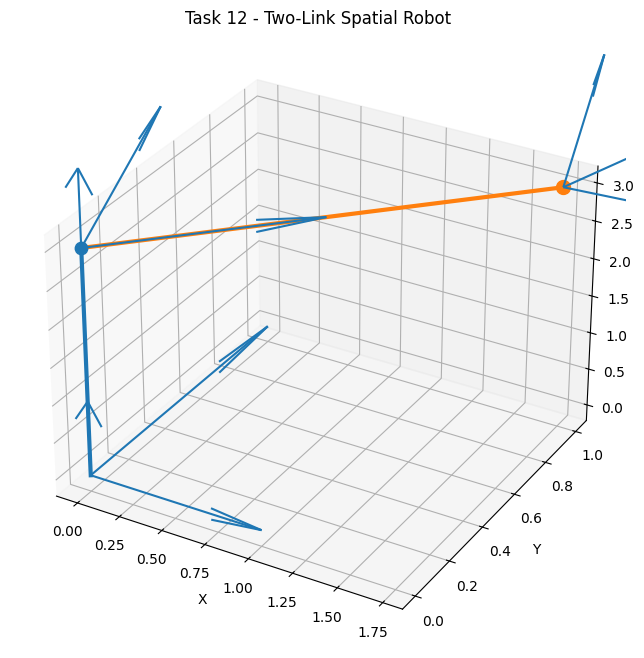


After Changing Rotation Angles:

New Overall Transformation
--------------------------------------------------
   0.3536   -0.7071    0.6124    1.414     
   0.3536    0.7071    0.6124    1.414     
  -0.866     0         0.5       3         
   0         0         0         1         


New End-Effector Position and Orientation:
Final X Position       : 1.4142
Final Y Position       : 1.4142
Final Z Position       : 3.0000

Final Rotation Matrix:
[[ 0.35355339 -0.70710678  0.61237244]
 [ 0.35355339  0.70710678  0.61237244]
 [-0.8660254   0.          0.5       ]]


In [14]:
# ================================================================
# TASK 12 - TWO-LINK SPATIAL ROBOT
# ================================================================

# Link 1
T_spatial_link1 = (
    SE3(0, 0, 3)
    * SE3.Rz(30, "deg")
)


# Link 2
T_spatial_link2 = (
    SE3(2, 0, 0)
    * SE3.Ry(45, "deg")
)


# Overall transformation
T_spatial_total = (
    T_spatial_link1
    * T_spatial_link2
)


print_matrix("Link 1 Transformation", T_spatial_link1)

print_matrix("Link 2 Transformation", T_spatial_link2)

print_matrix("Overall Transformation", T_spatial_total)


print("\nEnd-Effector Position and Orientation:")
print_position_orientation_3d(T_spatial_total)


# ---------------------------------------------------------------
# Plot Coordinate Frames
# ---------------------------------------------------------------

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')


# Base frame
ax.quiver(0, 0, 0, 1, 0, 0, length=1)
ax.quiver(0, 0, 0, 0, 1, 0, length=1)
ax.quiver(0, 0, 0, 0, 0, 1, length=1)


# Link 1 frame
p1 = T_spatial_link1.t
R1 = T_spatial_link1.R

ax.scatter(p1[0], p1[1], p1[2], s=80)

ax.quiver(p1[0], p1[1], p1[2],
          R1[0, 0],
          R1[1, 0],
          R1[2, 0],
          length=1)

ax.quiver(p1[0], p1[1], p1[2],
          R1[0, 1],
          R1[1, 1],
          R1[2, 1],
          length=1)

ax.quiver(p1[0], p1[1], p1[2],
          R1[0, 2],
          R1[1, 2],
          R1[2, 2],
          length=1)


# End-effector frame
p2 = T_spatial_total.t
R2 = T_spatial_total.R

ax.scatter(p2[0], p2[1], p2[2], s=100)

ax.quiver(p2[0], p2[1], p2[2],
          R2[0, 0],
          R2[1, 0],
          R2[2, 0],
          length=1)

ax.quiver(p2[0], p2[1], p2[2],
          R2[0, 1],
          R2[1, 1],
          R2[2, 1],
          length=1)

ax.quiver(p2[0], p2[1], p2[2],
          R2[0, 2],
          R2[1, 2],
          R2[2, 2],
          length=1)


# Plot links
ax.plot(
    [0, p1[0]],
    [0, p1[1]],
    [0, p1[2]],
    linewidth=3
)

ax.plot(
    [p1[0], p2[0]],
    [p1[1], p2[1]],
    [p1[2], p2[2]],
    linewidth=3
)


ax.set_title("Task 12 - Two-Link Spatial Robot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


# ---------------------------------------------------------------
# Change Rotation Angles
# ---------------------------------------------------------------

T_spatial_link1_changed = (
    SE3(0, 0, 3)
    * SE3.Rz(45, "deg")
)

T_spatial_link2_changed = (
    SE3(2, 0, 0)
    * SE3.Ry(60, "deg")
)

T_spatial_total_changed = (
    T_spatial_link1_changed
    * T_spatial_link2_changed
)


print("\nAfter Changing Rotation Angles:")

print_matrix(
    "New Overall Transformation",
    T_spatial_total_changed
)

print("\nNew End-Effector Position and Orientation:")

print_position_orientation_3d(
    T_spatial_total_changed
)



TASK 13A - PLANAR TRANSFORMATION

Planar Translation 1
--------------------------------------------------
   1         0         2         
   0         1         3         
   0         0         1         


Planar Rotation 1
--------------------------------------------------
   0.7071   -0.7071    0         
   0.7071    0.7071    0         
   0         0         1         


Planar Translation 2
--------------------------------------------------
   1         0         4         
   0         1         0         
   0         0         1         


Planar Rotation 2
--------------------------------------------------
   0.866    -0.5       0         
   0.5       0.866     0         
   0         0         1         


Final Planar Homogeneous Transformation
--------------------------------------------------
   0.2588   -0.9659    4.828     
   0.9659    0.2588    5.828     
   0         0         1         


Final Planar Position and Orientation:
Final X Position       : 4.8284


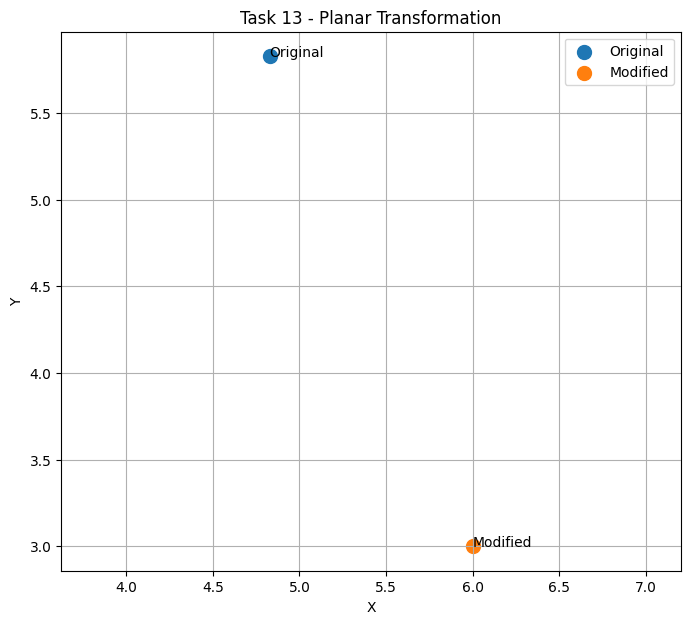



TASK 13B - SPATIAL TRANSFORMATION

Spatial Translation 1
--------------------------------------------------
   1         0         0         2         
   0         1         0         3         
   0         0         1         1         
   0         0         0         1         


Rotation about X - 30 degrees
--------------------------------------------------
   1         0         0         0         
   0         0.866    -0.5       0         
   0         0.5       0.866     0         
   0         0         0         1         


Rotation about Y - 45 degrees
--------------------------------------------------
   0.7071    0         0.7071    0         
   0         1         0         0         
  -0.7071    0         0.7071    0         
   0         0         0         1         


Spatial Translation 2
--------------------------------------------------
   1         0         0         1         
   0         1         0         2         
   0         0         1         

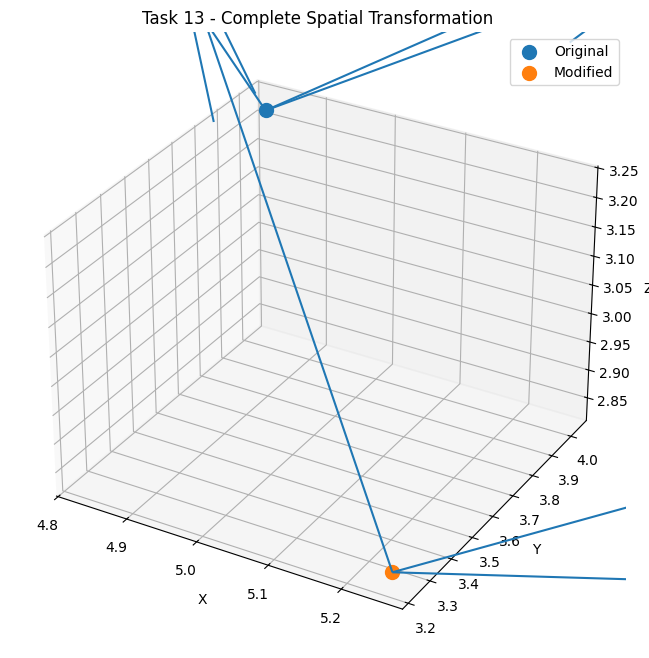

In [15]:
# ================================================================
# PART D - CHALLENGE TASK
# ================================================================


# ================================================================
# TASK 13 - COMPLETE TRANSFORMATION SEQUENCE
# ================================================================

# ================================================================
# TASK 13A - PLANAR CHALLENGE
# ================================================================

print_header("TASK 13A - PLANAR TRANSFORMATION")


P_T1 = SE2(2, 3)
P_R1 = SE2.Rot(45, "deg")
P_T2 = SE2(4, 0)
P_R2 = SE2.Rot(30, "deg")


print_matrix("Planar Translation 1", P_T1)
print_matrix("Planar Rotation 1", P_R1)
print_matrix("Planar Translation 2", P_T2)
print_matrix("Planar Rotation 2", P_R2)


# Given order
P_final = P_T1 * P_R1 * P_T2 * P_R2


print_matrix(
    "Final Planar Homogeneous Transformation",
    P_final
)


print("\nFinal Planar Position and Orientation:")
print_position_orientation_2d(P_final)


# ---------------------------------------------------------------
# Change order of transformations
# ---------------------------------------------------------------

P_modified = P_T1 * P_T2 * P_R1 * P_R2


print_matrix(
    "Modified Planar Transformation",
    P_modified
)


print("\nAre original and modified transformations identical?",
      np.allclose(P_final.A, P_modified.A))


# ---------------------------------------------------------------
# Plot Planar Challenge
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    P_final.t[0],
    P_final.t[1],
    s=100,
    label="Original"
)

ax.scatter(
    P_modified.t[0],
    P_modified.t[1],
    s=100,
    label="Modified"
)

ax.text(
    P_final.t[0],
    P_final.t[1],
    "Original"
)

ax.text(
    P_modified.t[0],
    P_modified.t[1],
    "Modified"
)

ax.set_title("Task 13 - Planar Transformation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
ax.axis("equal")
ax.legend()

plt.show()


# ================================================================
# TASK 13B - SPATIAL CHALLENGE
# ================================================================

print_header("TASK 13B - SPATIAL TRANSFORMATION")


S_T1 = SE3(2, 3, 1)
S_Rx = SE3.Rx(30, "deg")
S_Ry = SE3.Ry(45, "deg")
S_T2 = SE3(1, 2, 3)
S_Rz = SE3.Rz(60, "deg")


print_matrix("Spatial Translation 1", S_T1)
print_matrix("Rotation about X - 30 degrees", S_Rx)
print_matrix("Rotation about Y - 45 degrees", S_Ry)
print_matrix("Spatial Translation 2", S_T2)
print_matrix("Rotation about Z - 60 degrees", S_Rz)


# Given sequence
S_final = (
    S_T1
    * S_Rx
    * S_Ry
    * S_T2
    * S_Rz
)


print_matrix(
    "Final Spatial Homogeneous Transformation",
    S_final
)


print("\nFinal Spatial Position and Orientation:")
print_position_orientation_3d(S_final)


# ---------------------------------------------------------------
# Change order of transformations
# ---------------------------------------------------------------

S_modified = (
    S_T1
    * S_Ry
    * S_Rx
    * S_T2
    * S_Rz
)


print_matrix(
    "Modified Spatial Transformation",
    S_modified
)


print("\nAre original and modified transformations identical?",
      np.allclose(S_final.A, S_modified.A))


# ---------------------------------------------------------------
# Plot Spatial Challenge
# ---------------------------------------------------------------

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')


# Original final frame
p_original = S_final.t
R_original = S_final.R

ax.scatter(
    p_original[0],
    p_original[1],
    p_original[2],
    s=100,
    label="Original"
)


# Original X axis
ax.quiver(
    p_original[0],
    p_original[1],
    p_original[2],
    R_original[0, 0],
    R_original[1, 0],
    R_original[2, 0],
    length=1
)

# Original Y axis
ax.quiver(
    p_original[0],
    p_original[1],
    p_original[2],
    R_original[0, 1],
    R_original[1, 1],
    R_original[2, 1],
    length=1
)

# Original Z axis
ax.quiver(
    p_original[0],
    p_original[1],
    p_original[2],
    R_original[0, 2],
    R_original[1, 2],
    R_original[2, 2],
    length=1
)


# Modified final frame
p_modified = S_modified.t
R_modified = S_modified.R

ax.scatter(
    p_modified[0],
    p_modified[1],
    p_modified[2],
    s=100,
    label="Modified"
)


# Modified X axis
ax.quiver(
    p_modified[0],
    p_modified[1],
    p_modified[2],
    R_modified[0, 0],
    R_modified[1, 0],
    R_modified[2, 0],
    length=1
)

# Modified Y axis
ax.quiver(
    p_modified[0],
    p_modified[1],
    p_modified[2],
    R_modified[0, 1],
    R_modified[1, 1],
    R_modified[2, 1],
    length=1
)

# Modified Z axis
ax.quiver(
    p_modified[0],
    p_modified[1],
    p_modified[2],
    R_modified[0, 2],
    R_modified[1, 2],
    R_modified[2, 2],
    length=1
)


ax.set_title("Task 13 - Complete Spatial Transformation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()